# MVTec AD 이미지 검색 성능 평가 실습

**MVTec AD** 동일 데이터셋으로 **SigLIP2(CLIP 계열)** 이미지 임베딩을 생성하고,
**ChromaDB**·**FAISS**에 저장한 뒤 **질의 이미지**로 유사 검색 성능을 측정합니다.

> **선행 학습**: `06_mvtec_db_visual_intelligence.ipynb` (MVTec 데이터·SigLIP2·ChromaDB 개념)

## 전체 흐름

```
MVTec AD test 이미지 (244장)
       ↓
SigLIP2 이미지 임베딩
       ↓
ChromaDB / FAISS 저장
       ↓
질의 이미지 → Top-k 검색
       ↓
Recall@K · Precision@K 계산
       ↓
Top-5 → Top-10 · 임계값(Threshold) 변경 → 성능 비교
```

| 단계 | 내용 |
|------|------|
| **임베딩** | `SigLIP2Encoder.encode_images` — L2 정규화 벡터 |
| **저장소** | ChromaDB (`mvtec_eval_siglip2`) · FAISS (`IndexFlatIP`) |
| **질의** | test 이미지 1장 → 동일 벡터 공간에서 유사 이미지 검색 |
| **정답 기준** | 동일 **품목(product)** + 동일 **결함유형(defect_type)** (자기 자신 제외) |
| **지표** | Recall@K, Precision@K |
| **비교** | Top-5 vs Top-10, 임계값 0.5~0.9, ChromaDB vs FAISS |

### 모듈 소스 참조

📄 **[00_모듈_참조.md](00_모듈_참조.md)**

| 노트북에서 import | 경로 |
|-------------------|------|
| `SigLIP2Encoder` | `conveyor_analyze/conveyor_rag/encoder.py` |
| `scan_test_images` | `mvtec_analyze/mvtec_rag/dataset.py` |
| `MVTecStore` | `mvtec_analyze/mvtec_rag/store.py` (06번 ChromaDB 참고) |

## 0. 환경 설정

**사전 준비**
<br>
1. 프로젝트 루트에 `MVTec_581MB.zip` 배치 후 `data/mvtec` 압축 해제 (06번과 동일)<br>
2. `pip install -r mvtec_analyze/requirements.txt`<br>
3. FAISS 비교 실습: `pip install faiss-cpu` (GPU 환경은 `faiss-gpu` 가능)

In [1]:
# !pip install -r mvtec_analyze/requirements.txt
# mvtec_analyze 패키지 의존성 설치 — torch, transformers, chromadb, pandas 등
# !pip install faiss-cpu
# FAISS 벡터 검색 라이브러리 — ChromaDB와 검색 속도·결과 비교 실습에 사용


In [2]:
import sys
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt  # 검색 결과·성능 비교 차트 시각화
import numpy as np
import pandas as pd  # 메타데이터 집계·비교표 DataFrame
from IPython.display import Markdown, display
from PIL import Image  # MVTec PNG 이미지 로드
from tqdm import tqdm  # 임베딩 배치 진행률 표시

# --- 경로 상수 ---
# 노트북 실행 위치(09_Visual_RAG)를 프로젝트 루트로 사용
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data" / "mvtec"            # MVTec AD 압축 해제·DB 루트 (06번과 동일)
MVTEC_ZIP = ROOT / "MVTec_581MB.zip"          # 원본 ZIP (최초 압축 해제용)
EVAL_CHROMA_DIR = DATA_DIR / "chroma_db_eval" # 평가 전용 ChromaDB — 06번 mvtec_siglip2와 분리
EVAL_COLLECTION = "mvtec_eval_siglip2"        # 평가 실습용 컬렉션명

# mvtec_rag·conveyor_rag(SigLIP2) import 가능하도록 sys.path 등록
sys.path.insert(0, str(ROOT / "mvtec_analyze"))
sys.path.insert(0, str(ROOT / "conveyor_analyze"))

from conveyor_rag.encoder import SigLIP2Encoder       # CLIP 계열 SigLIP2 이미지 임베딩
from conveyor_rag.plot_utils import setup_korean_matplotlib
from mvtec_rag.config import PRODUCTS                 # MVTec 15개 품목 목록
from mvtec_rag.dataset import scan_test_images        # test/ 폴더 이미지 메타 스캔

# matplotlib 차트 한글 폰트 (Windows: Malgun Gothic 등)
_font = setup_korean_matplotlib()
print(f"ROOT: {ROOT}")
print(f"데이터: {DATA_DIR.exists()}")
print(f"matplotlib 한글: {_font}")


ROOT: C:\MyCursorLab\09_Visual_RAG
데이터: True
matplotlib 한글: Malgun Gothic


## 1. MVTec AD 데이터 확인

06번과 동일한 **test/** 이미지(정상 `good` + 결함 유형)를 검색 갤러리로 사용합니다.

In [3]:
# data/mvtec 가 비어 있으면 ZIP → 폴더 압축 해제 (최초 1회, 수 분 소요)
if not DATA_DIR.exists() or not any((DATA_DIR / p).is_dir() for p in PRODUCTS):
    if not MVTEC_ZIP.exists():
        raise FileNotFoundError("MVTec_581MB.zip 을 프로젝트 루트에 배치하세요.")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print("압축 해제 중...")
    with zipfile.ZipFile(MVTEC_ZIP) as z:
        z.extractall(DATA_DIR)
    print("완료")

# test/ 이미지 메타 수집 — product, defect_type, label, image_path
records = scan_test_images(DATA_DIR)
df_meta = pd.DataFrame(records)
print(f"test 이미지: {len(records)}장")
# 품목·결함유형별 이미지 수 미리보기 (갤러리 구성 확인)
display(df_meta.groupby(["product", "defect_type"]).size().reset_index(name="count").head(12))


test 이미지: 244장


,product,defect_type,count
0,bottle,broken_large,3
1,bottle,broken_small,3
2,bottle,contamination,3
3,bottle,good,3
4,cable,bent_wire,2
5,cable,cable_swap,2
6,cable,combined,2
7,cable,cut_inner_insulation,2
8,cable,cut_outer_insulation,2
9,cable,good,7


## 2. SigLIP2 임베딩 생성

모든 test 이미지를 **SigLIP2**로 인코딩합니다. L2 정규화 벡터이므로 코사인 유사도 = 내적입니다.

In [4]:
# SigLIP2 모델 로드 — GPU 사용 가능 시 cuda + float16
encoder = SigLIP2Encoder()
BATCH_SIZE = 16  # GPU VRAM에 맞게 조절 (OOM 시 8 또는 4)

all_embeddings = []
# 전체 test 이미지를 배치 단위로 인코딩 — L2 정규화 벡터 반환
for start in tqdm(range(0, len(records), BATCH_SIZE), desc="SigLIP2 임베딩"):
    batch = records[start : start + BATCH_SIZE]
    images = [Image.open(r["image_path"]).convert("RGB") for r in batch]
    embs = encoder.encode_images(images)
    all_embeddings.append(embs)

# (N, dim) float32 배열 — ChromaDB·FAISS 공통 입력
embeddings = np.vstack(all_embeddings).astype(np.float32)
print(f"임베딩 shape: {embeddings.shape}")


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SigLIP2 임베딩: 100%|██████████| 16/16 [00:27<00:00,  1.74s/it]

임베딩 shape: (244, 1152)


## 3. ChromaDB · FAISS 저장

| 저장소 | 특징 |
|--------|------|
| **ChromaDB** | 메타데이터 내장, `where` 필터, 영구 저장 |
| **FAISS** | 고속 벡터 검색, 메타는 별도 리스트로 관리 |

In [5]:
import hashlib
import chromadb

# 평가용 ChromaDB 디렉터리 생성
EVAL_CHROMA_DIR.mkdir(parents=True, exist_ok=True)
# 디스크 영구 저장 — 노트북 재실행 시에도 벡터 유지 가능
chroma_client = chromadb.PersistentClient(path=str(EVAL_CHROMA_DIR))
# 이전 실습 결과가 있으면 컬렉션 삭제 후 새로 구축
try:
    chroma_client.delete_collection(EVAL_COLLECTION)
except Exception:
    pass
chroma_col = chroma_client.get_or_create_collection(
    name=EVAL_COLLECTION,
    metadata={"hnsw:space": "cosine"},  # SigLIP2 L2 정규화 임베딩 → cosine = 내적
)

ids, metas, embs = [], [], []
for rec, emb in zip(records, embeddings):
    # product + defect_type + path 조합으로 고유 id — 재인덱싱 시 upsert로 덮어쓰기
    key = f"{rec['product']}_{rec['defect_type']}_{rec['image_path']}"
    ids.append(hashlib.md5(key.encode()).hexdigest()[:16])
    # 검색 결과·평가에 product/label/image_path 포함
    metas.append({
        "product": rec["product"],
        "defect_type": rec["defect_type"],
        "label": rec["label"],
        "image_path": rec["image_path"],
    })
    embs.append(emb.tolist())

# upsert: 동일 id면 갱신 — 재실행 시 중복 방지
chroma_col.upsert(ids=ids, embeddings=embs, metadatas=metas)
print(f"ChromaDB: {chroma_col.count()}건 → {EVAL_CHROMA_DIR}")


ChromaDB: 244건 → C:\MyCursorLab\09_Visual_RAG\data\mvtec\chroma_db_eval


In [6]:
try:
    import faiss
except ImportError:
    raise ImportError("FAISS 실습을 위해 `pip install faiss-cpu` 를 실행하세요.")

dim = embeddings.shape[1]
# IndexFlatIP: L2 정규화 벡터의 내적 = 코사인 유사도 (정확한 전수 검색)
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(embeddings)
# FAISS는 벡터만 저장 — 메타데이터는 별도 리스트로 인덱스와 1:1 대응
faiss_metas = metas.copy()
print(f"FAISS: {faiss_index.ntotal}건, dim={dim}")


FAISS: 244건, dim=1152


## 4. 검색 함수 · 평가 지표

### 정답(Relevant) 정의

질의 이미지와 **같은 품목 + 같은 결함유형**인 갤러리 이미지가 정답입니다. (질의 자신은 제외)

$$\text{Recall@K} = \frac{|\text{Top-K} \cap \text{Relevant}|}{|\text{Relevant}|}$$

$$\text{Precision@K} = \frac{|\text{Top-K} \cap \text{Relevant}|}{K}$$

**임계값(Threshold)**: 유사도가 `threshold` 미만인 결과는 제외한 뒤 지표를 계산합니다.

In [7]:
def is_relevant(query_rec: dict, candidate_meta: dict) -> bool:
    """질의와 후보가 동일 품목·결함유형이면 정답(Relevant)."""
    # 갤러리 질의 시 자기 자신은 정답에서 제외
    if query_rec["image_path"] == candidate_meta["image_path"]:
        return False
    return (
        query_rec["product"] == candidate_meta["product"]
        and query_rec["defect_type"] == candidate_meta["defect_type"]
    )


def count_relevant(query_rec: dict, gallery: list[dict]) -> int:
    """갤러리 전체에서 질의에 대한 정답 이미지 수 (자기 자신 제외)."""
    return sum(1 for g in gallery if is_relevant(query_rec, g))


def apply_threshold(hits: list[dict], threshold: float) -> list[dict]:
    """유사도가 threshold 미만인 검색 결과를 제거."""
    if threshold <= 0:
        return hits
    return [h for h in hits if h["similarity"] >= threshold]


def exclude_self(hits: list[dict], query_rec: dict) -> list[dict]:
    """갤러리 질의 시 자기 자신(동일 경로)을 검색 결과에서 제외."""
    return [h for h in hits if h["metadata"]["image_path"] != query_rec["image_path"]]


def recall_precision_at_k(hits: list[dict], query_rec: dict, k: int, gallery: list[dict]) -> tuple[float, float]:
    """
    Recall@K = Top-K 중 정답 수 / 전체 정답 수
    Precision@K = Top-K 중 정답 수 / K
    """
    relevant_total = count_relevant(query_rec, gallery)
    top_k = hits[:k]
    found = sum(1 for h in top_k if is_relevant(query_rec, h["metadata"]))
    # 정답이 0건이면 recall=1.0 (분모 0 방지)
    recall = found / relevant_total if relevant_total > 0 else 1.0
    precision = found / k if k > 0 else 0.0
    return recall, precision


def search_chroma(query_emb: np.ndarray, top_k: int = 5) -> list[dict]:
    """ChromaDB cosine 검색 — distance를 similarity(1-distance)로 변환."""
    n = min(top_k, chroma_col.count())
    result = chroma_col.query(
        query_embeddings=[query_emb.tolist()],
        n_results=n,
        include=["metadatas", "distances"],
    )
    hits = []
    for i in range(len(result["ids"][0])):
        hits.append({
            "id": result["ids"][0][i],
            # cosine distance → similarity (1에 가까울수록 유사)
            "similarity": 1.0 - result["distances"][0][i],
            "metadata": result["metadatas"][0][i],
        })
    return hits


def search_faiss(query_emb: np.ndarray, top_k: int = 5) -> list[dict]:
    """FAISS IndexFlatIP 검색 — 내적 점수가 곧 코사인 유사도."""
    q = query_emb.reshape(1, -1).astype(np.float32)
    n = min(top_k, faiss_index.ntotal)
    scores, indices = faiss_index.search(q, n)
    hits = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue  # FAISS 빈 슬롯
        hits.append({
            "id": str(idx),
            "similarity": float(score),
            "metadata": faiss_metas[idx],
        })
    return hits


def evaluate_setting(
    search_fn,
    query_indices: list[int],
    top_k: int,
    threshold: float,
    fetch_k: int | None = None,
) -> dict:
    """전체 질의에 대해 평균 Recall@K, Precision@K, 검색 시간 측정."""
    # threshold 적용 시 걸러질 여유를 위해 fetch_k만큼 먼저 가져옴
    fetch_k = fetch_k or top_k
    recalls, precisions, hit_counts = [], [], []
    t0 = time.perf_counter()
    for qi in query_indices:
        query_rec = records[qi]
        query_emb = embeddings[qi]
        # +1: 자기 자신 제외 후에도 top_k를 채우기 위함
        raw_hits = search_fn(query_emb, top_k=fetch_k + 1)
        raw_hits = exclude_self(raw_hits, query_rec)
        hits = apply_threshold(raw_hits, threshold)
        r, p = recall_precision_at_k(hits, query_rec, top_k, records)
        recalls.append(r)
        precisions.append(p)
        hit_counts.append(len(hits))
    elapsed = time.perf_counter() - t0
    return {
        "recall": float(np.mean(recalls)),
        "precision": float(np.mean(precisions)),
        "avg_hits": float(np.mean(hit_counts)),
        "queries": len(query_indices),
        "elapsed_sec": elapsed,
        "ms_per_query": elapsed / max(len(query_indices), 1) * 1000,
    }


## 5. 질의 이미지 Top-5 검색 (단일 예시)

한 장의 test 이미지를 질의로 넣고 유사 이미지 Top-5를 확인합니다.

In [8]:
# 단일 질의 예시 — records 인덱스를 바꿔 다른 이미지로 실험 가능
QUERY_IDX = 42
query_rec = records[QUERY_IDX]
query_emb = embeddings[QUERY_IDX]  # 미리 계산한 임베딩 재사용 (재인코딩 불필요)
TOP_K = 5

# ChromaDB Top-(K+1) 검색 후 자기 자신 제외 → Top-K
hits5 = exclude_self(search_chroma(query_emb, top_k=TOP_K + 1), query_rec)[:TOP_K]
r5, p5 = recall_precision_at_k(hits5, query_rec, TOP_K, records)

print(f"질의: {query_rec['product']} / {query_rec['defect_type']} ({query_rec['label']})")
print(f"정답 후보 수(자기 제외): {count_relevant(query_rec, records)}")
print(f"Recall@{TOP_K}: {r5:.3f}  Precision@{TOP_K}: {p5:.3f}")
print()
for i, h in enumerate(hits5, 1):
    m = h["metadata"]
    rel = "✓" if is_relevant(query_rec, m) else " "  # ✓ = 동일 품목·결함유형 정답
    print(f"{i}. [{rel}] sim={h['similarity']:.3f} | {m['product']}/{m['defect_type']} | {Path(m['image_path']).name}")


질의: capsule / good (정상)
정답 후보 수(자기 제외): 2
Recall@5: 0.500  Precision@5: 0.200

1. [✓] sim=0.996 | capsule/good | 004.png
2. [ ] sim=0.994 | capsule/scratch | 019.png
3. [ ] sim=0.993 | capsule/squeeze | 008.png
4. [ ] sim=0.991 | capsule/crack | 016.png
5. [ ] sim=0.990 | capsule/poke | 002.png


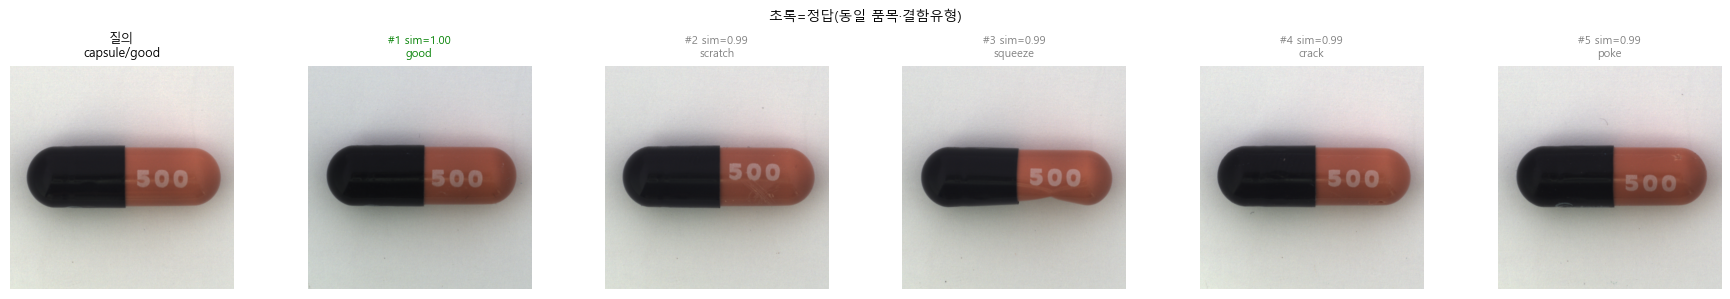

In [9]:
def show_query_results(query_rec: dict, hits: list[dict], top_k: int = 5):
    """질의 이미지 + Top-k 검색 결과를 가로로 시각화."""
    n = min(top_k, len(hits))
    fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 3))
    # 첫 칸: 질의 이미지
    axes[0].imshow(Image.open(query_rec["image_path"]))
    axes[0].set_title(f"질의\n{query_rec['product']}/{query_rec['defect_type']}", fontsize=9)
    axes[0].axis("off")
    for i in range(n):
        m = hits[i]["metadata"]
        rel = is_relevant(query_rec, m)
        color = "green" if rel else "gray"  # 초록 = 정답, 회색 = 오답
        axes[i + 1].imshow(Image.open(m["image_path"]))
        axes[i + 1].set_title(
            f"#{i+1} sim={hits[i]['similarity']:.2f}\n{m['defect_type']}",
            fontsize=8,
            color=color,
        )
        axes[i + 1].axis("off")
    plt.suptitle("초록=정답(동일 품목·결함유형)", fontsize=10)
    plt.tight_layout()
    plt.show()

show_query_results(query_rec, hits5, TOP_K)


## 6. 전체 질의 Recall@5 · Precision@5

모든 test 이미지를 질의로 사용해 평균 지표를 계산합니다. (처음 실행 시 수십 초 소요)

In [10]:
# 모든 test 이미지를 질의로 사용 — leave-one-out 스타일 전수 평가
QUERY_INDICES = list(range(len(records)))

result_top5 = evaluate_setting(search_chroma, QUERY_INDICES, top_k=5, threshold=0.0)
display(Markdown(
    f"""### Top-5 (임계값 없음)
- **Recall@5**: {result_top5['recall']:.4f}
- **Precision@5**: {result_top5['precision']:.4f}
- 평균 반환 건수: {result_top5['avg_hits']:.1f}
- 검색 시간: {result_top5['elapsed_sec']:.2f}s ({result_top5['ms_per_query']:.1f} ms/질의)
"""
))


### Top-5 (임계값 없음)
- **Recall@5**: 0.6539
- **Precision@5**: 0.2754
- 평균 반환 건수: 5.0
- 검색 시간: 0.36s (1.5 ms/질의)


## 7. Top-10으로 변경 · 성능 비교

K를 5→10으로 늘리면 Recall은 올라가고 Precision은 낮아지는 경향이 있습니다.

,Top-K,Recall@K,Precision@K,avg_hits
0,5,0.6539,0.2754,5.0
1,10,0.8412,0.1807,10.0


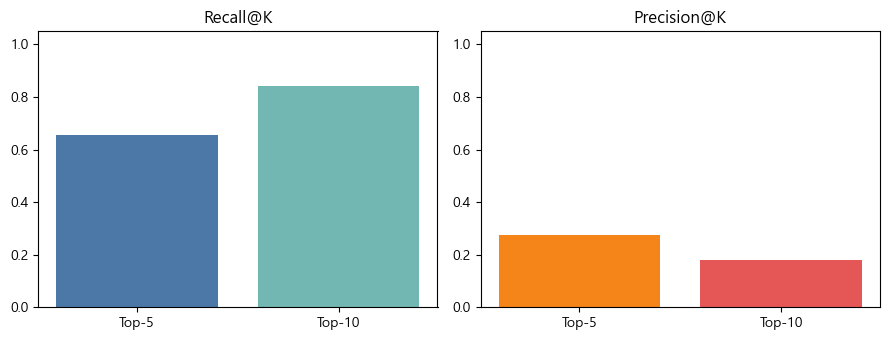

In [11]:
# Top-K를 10으로 확대 — Recall↑ Precision↓ 경향 관찰
result_top10 = evaluate_setting(search_chroma, QUERY_INDICES, top_k=10, threshold=0.0)

compare_k = pd.DataFrame([
    {"Top-K": 5, "Recall@K": result_top5["recall"], "Precision@K": result_top5["precision"], "avg_hits": result_top5["avg_hits"]},
    {"Top-K": 10, "Recall@K": result_top10["recall"], "Precision@K": result_top10["precision"], "avg_hits": result_top10["avg_hits"]},
])
display(compare_k.style.format({"Recall@K": "{:.4f}", "Precision@K": "{:.4f}", "avg_hits": "{:.1f}"}))

# Recall@K · Precision@K 막대 그래프 비교
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
labels = ["Top-5", "Top-10"]
ax[0].bar(labels, [result_top5["recall"], result_top10["recall"]], color=["#4C78A8", "#72B7B2"])
ax[0].set_title("Recall@K")
ax[0].set_ylim(0, 1.05)
ax[1].bar(labels, [result_top5["precision"], result_top10["precision"]], color=["#F58518", "#E45756"])
ax[1].set_title("Precision@K")
ax[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 8. 임계값(Threshold) 변경 · 성능 비교

유사도가 낮은 결과를 걸러 **정밀도**를 높일 수 있습니다. 임계값을 올리면 반환 건수가 줄어듭니다.

In [12]:
# 임계값별·Top-K별 그리드 실험
THRESHOLDS = [0.0, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_rows = []

for th in THRESHOLDS:
    for k in [5, 10]:
        res = evaluate_setting(
            search_chroma,
            QUERY_INDICES,
            top_k=k,
            threshold=th,
            fetch_k=max(k, 20),  # threshold 필터 후에도 k개를 채울 여유 확보
        )
        threshold_rows.append({
            "Top-K": k,
            "Threshold": th,
            "Recall@K": res["recall"],
            "Precision@K": res["precision"],
            "avg_hits": res["avg_hits"],
        })

df_threshold = pd.DataFrame(threshold_rows)
# 피벗 테이블 — 행=임계값, 열=Top-K별 Recall/Precision
display(df_threshold.pivot_table(
    index="Threshold", columns="Top-K",
    values=["Recall@K", "Precision@K"], aggfunc="first"
).round(4))


Precision@K         Recall@K        
Top-K              5       10       5       10
Threshold                                     
0.0            0.2754  0.1807   0.6539  0.8412
0.5            0.2754  0.1807   0.6539  0.8412
0.6            0.2754  0.1807   0.6539  0.8412
0.7            0.2754  0.1807   0.6539  0.8412
0.8            0.2754  0.1807   0.6539  0.8412
0.9            0.2721  0.1770   0.6416  0.8187

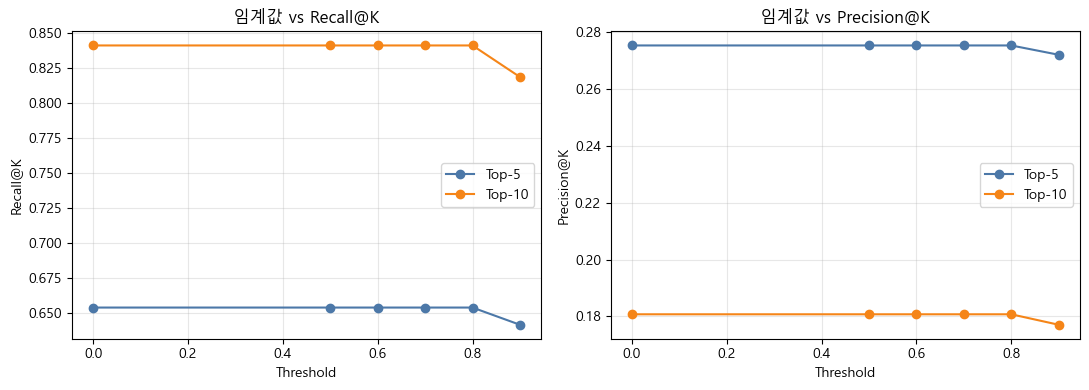

In [13]:
# 임계값 변화에 따른 Recall@K · Precision@K 추이 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for k, color in [(5, "#4C78A8"), (10, "#F58518")]:
    sub = df_threshold[df_threshold["Top-K"] == k]
    axes[0].plot(sub["Threshold"], sub["Recall@K"], marker="o", label=f"Top-{k}", color=color)
    axes[1].plot(sub["Threshold"], sub["Precision@K"], marker="o", label=f"Top-{k}", color=color)
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Recall@K")
axes[0].set_title("임계값 vs Recall@K")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Precision@K")
axes[1].set_title("임계값 vs Precision@K")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. ChromaDB vs FAISS 성능 비교

동일 SigLIP2 벡터·동일 Top-K에서 검색 결과 일치 여부와 속도를 비교합니다.

In [14]:
# ChromaDB vs FAISS — 동일 30질의 샘플로 속도·지표·결과 일치율 비교
sample_idx = QUERY_INDICES[:30]
chroma_eval = evaluate_setting(search_chroma, sample_idx, top_k=5, threshold=0.0)
faiss_eval = evaluate_setting(search_faiss, sample_idx, top_k=5, threshold=0.0)

# Top-5 검색 경로가 백엔드 간 동일한지 확인
match_count = 0
for qi in sample_idx:
    h_c = exclude_self(search_chroma(embeddings[qi], top_k=6), records[qi])[:5]
    h_f = exclude_self(search_faiss(embeddings[qi], top_k=6), records[qi])[:5]
    paths_c = [h["metadata"]["image_path"] for h in h_c]
    paths_f = [h["metadata"]["image_path"] for h in h_f]
    if paths_c == paths_f:
        match_count += 1

df_backend = pd.DataFrame([
    {"Backend": "ChromaDB", **{k: chroma_eval[k] for k in ["recall", "precision", "ms_per_query"]}},
    {"Backend": "FAISS", **{k: faiss_eval[k] for k in ["recall", "precision", "ms_per_query"]}},
])
display(df_backend.rename(columns={"recall": "Recall@5", "precision": "Precision@5", "ms_per_query": "ms/질의"}))
print(f"Top-5 경로 일치율 (30질의): {match_count}/{len(sample_idx)}")


,Backend,Recall@5,Precision@5,ms/질의
0,ChromaDB,0.516667,0.233333,1.706717
1,FAISS,0.516667,0.233333,0.065923


Top-5 경로 일치율 (30질의): 18/30


## 10. 종합 성능 비교표

| 실험 | 설명 |
|------|------|
| Baseline Top-5 | 임계값 없음, K=5 |
| Top-10 | K만 10으로 확대 |
| Threshold 0.7 | 유사도 0.7 미만 제외 |
| FAISS Top-5 | 동일 지표, FAISS 백엔드 |

In [15]:
# 종합 비교 — Baseline / Top-10 / Threshold / FAISS 실험 결과 한눈에
res_th07_k5 = evaluate_setting(search_chroma, QUERY_INDICES, top_k=5, threshold=0.7, fetch_k=20)
res_th07_k10 = evaluate_setting(search_chroma, QUERY_INDICES, top_k=10, threshold=0.7, fetch_k=20)
res_faiss_k5 = evaluate_setting(search_faiss, QUERY_INDICES, top_k=5, threshold=0.0)

summary = pd.DataFrame([
    {"실험": "Baseline Top-5", "Top-K": 5, "Threshold": 0.0, "Backend": "ChromaDB",
     "Recall@K": result_top5["recall"], "Precision@K": result_top5["precision"], "ms/질의": result_top5["ms_per_query"]},
    {"실험": "Top-10 확대", "Top-K": 10, "Threshold": 0.0, "Backend": "ChromaDB",
     "Recall@K": result_top10["recall"], "Precision@K": result_top10["precision"], "ms/질의": result_top10["ms_per_query"]},
    {"실험": "Threshold 0.7 (K=5)", "Top-K": 5, "Threshold": 0.7, "Backend": "ChromaDB",
     "Recall@K": res_th07_k5["recall"], "Precision@K": res_th07_k5["precision"], "ms/질의": res_th07_k5["ms_per_query"]},
    {"실험": "Threshold 0.7 (K=10)", "Top-K": 10, "Threshold": 0.7, "Backend": "ChromaDB",
     "Recall@K": res_th07_k10["recall"], "Precision@K": res_th07_k10["precision"], "ms/질의": res_th07_k10["ms_per_query"]},
    {"실험": "FAISS Top-5", "Top-K": 5, "Threshold": 0.0, "Backend": "FAISS",
     "Recall@K": res_faiss_k5["recall"], "Precision@K": res_faiss_k5["precision"], "ms/질의": res_faiss_k5["ms_per_query"]},
])
display(summary.style.format({"Recall@K": "{:.4f}", "Precision@K": "{:.4f}", "ms/질의": "{:.2f}"}).hide(axis="index"))


실험,Top-K,Threshold,Backend,Recall@K,Precision@K,ms/질의
Baseline Top-5,5,0.000000,ChromaDB,0.6539,0.2754,1.49
Top-10 확대,10,0.000000,ChromaDB,0.8412,0.1807,2.04
Threshold 0.7 (K=5),5,0.700000,ChromaDB,0.6539,0.2754,1.82
Threshold 0.7 (K=10),10,0.700000,ChromaDB,0.8412,0.1807,1.99
FAISS Top-5,5,0.000000,FAISS,0.6586,0.2762,0.09


## 11. 정리

| 학습 포인트 | 내용 |
|-------------|------|
| **이미지 질의 검색** | SigLIP2 임베딩으로 "비슷한 결함 사진" 검색 |
| **Recall@K** | 정답 중 Top-K에 얼마나 포함되었는가 (재현율) |
| **Precision@K** | Top-K 중 정답 비율 (정밀도) |
| **Top-K 확대** | K↑ → Recall↑, Precision↓ 경향 |
| **Threshold** | 낮은 유사도 제거 → Precision↑, 반환 건수↓ |
| **ChromaDB vs FAISS** | 지표는 동일, FAISS가 대규모에서 더 빠른 경우 많음 |

